In [ ]:
import cv2
from src import utils
import matplotlib.pyplot as plt
from src.doc_layout import LayoutExtractor
from src.doc_ocr import ImageDescription

/home/lameus/miniconda3/envs/doc_parser/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
layout_extractor = LayoutExtractor(save_img=True,
                                   device="cuda")

doc_path = "./Siemens-VGD.pdf"

bboxes = layout_extractor.get_bboxes(doc_path=doc_path, output_path="example")


0: 1024x736 4 titles, 10 plain texts, 6 abandons, 3 figures, 1 figure_caption, 88.3ms
1: 1024x736 10 titles, 23 plain texts, 3 abandons, 1 figure, 88.3ms
2: 1024x736 3 titles, 15 plain texts, 4 abandons, 3 figures, 1 table, 88.3ms
3: 1024x736 4 titles, 13 plain texts, 5 abandons, 2 figures, 1 figure_caption, 1 table, 3 table_captions, 88.3ms
4: 1024x736 1 title, 9 plain texts, 4 abandons, 2 figures, 3 figure_captions, 88.3ms
5: 1024x736 2 titles, 3 plain texts, 3 abandons, 1 figure, 3 tables, 2 table_captions, 1 table_footnote, 88.3ms
6: 1024x736 5 titles, 15 plain texts, 4 abandons, 3 tables, 88.3ms
7: 1024x736 2 titles, 4 plain texts, 4 abandons, 1 figure, 5 tables, 3 table_captions, 1 table_footnote, 88.3ms
8: 1024x736 4 abandons, 1 figure, 1 table_footnote, 88.3ms
9: 1024x736 2 titles, 10 plain texts, 2 abandons, 1 figure, 2 tables, 88.3ms
10: 1024x736 2 titles, 12 plain texts, 4 abandons, 1 figure, 1 table, 1 table_caption, 88.3ms
11: 1024x736 1 title, 1 plain text, 6 abandons, 2

In [4]:
layout_extractor._find_closest_bboxes()

In [5]:
layout_extractor.relevant_pairs

[{'caption_id': 0, 'element_id': 1, 'similarity': 0.9871072877216799},
 {'caption_id': 1, 'element_id': 8, 'similarity': 0.43757619592093366},
 {'caption_id': 2, 'element_id': 8, 'similarity': 0.6162878659887562},
 {'caption_id': 3, 'element_id': 8, 'similarity': 0.8338008989833967},
 {'caption_id': 4, 'element_id': 9, 'similarity': 0.9971966419451285},
 {'caption_id': 5, 'element_id': 12, 'similarity': 0.999402648752226},
 {'caption_id': 6, 'element_id': 12, 'similarity': 0.9966795535487911},
 {'caption_id': 7, 'element_id': 12, 'similarity': 0.9456749637467318},
 {'caption_id': 8, 'element_id': 15, 'similarity': 0.9856192719091393},
 {'caption_id': 9, 'element_id': 15, 'similarity': 0.9790689650950513},
 {'caption_id': 10, 'element_id': 15, 'similarity': 0.9991767831592863},
 {'caption_id': 11, 'element_id': 20, 'similarity': 0.9742638574420436},
 {'caption_id': 12, 'element_id': 20, 'similarity': 0.9130719951156359},
 {'caption_id': 13, 'element_id': 20, 'similarity': 0.965986342650

### Пример объединения boudning box'ов

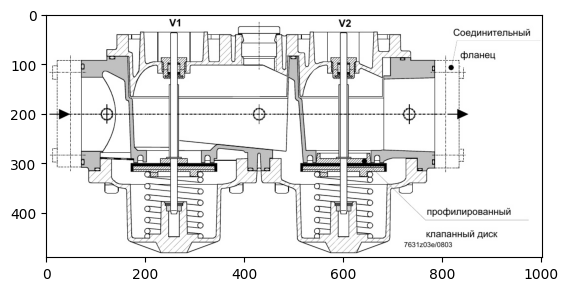

In [9]:
img = utils.readb64(eval(layout_extractor.specific_elems[9]["image_bytes"]))
img_rgb_2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert for matplotlib
plt.imshow(img_rgb_2)

In [10]:
layout_extractor._merge_related_bboxes()

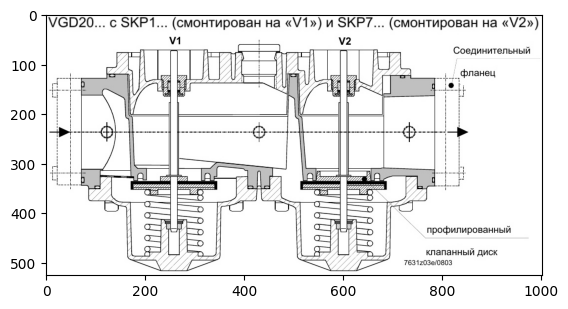

In [12]:
a = utils.readb64(layout_extractor.bbox_json[98]["image_bytes"])
a = cv2.cvtColor(a, cv2.COLOR_BGR2RGB)  # Convert for matplotlib
plt.imshow(a)

In [ ]:
import os, copy, json
from src.utils.visualize import save_layout_visualization

save_layout_visualization(layout_extractor, out_dir="out_viz", prefix="before")

# with open("out_viz/before/bboxes_before.json", "w", encoding="utf-8") as f:
#     json.dump(layout_extractor.bbox_json, f, ensure_ascii=False, indent=2)

layout_extractor._merge_adjacent_plain_texts(distance_ratio=0.25, abs_gap_px=18)
layout_extractor._detect_captions_around_figures(distance_ratio=0.1)

save_layout_visualization(layout_extractor, out_dir="out_viz", prefix="after")

# with open("out_viz/after/bboxes_after.json", "w", encoding="utf-8") as f:
#     json.dump(layout_extractor.bbox_json, f, ensure_ascii=False, indent=2)

In [ ]:
eval(layout_extractor.specific_elems[0]["image_bytes"])

In [15]:
ocr_model = ImageDescription(use_api=True,
                             bbox_json=layout_extractor.bbox_json)

In [ ]:
img_path = "./Siemens-VGD_layout_0.jpg"

In [17]:
ocr_model.load_doc(img_path)

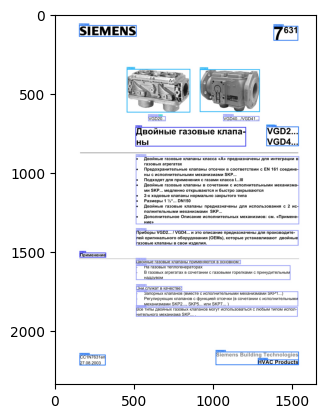

In [18]:
plt.imshow(ocr_model.image)

Инференс vlm с заданным bbox (через координаты)

In [21]:
vlm_answer = ocr_model.inference(bounding_box=layout_extractor.bboxes[0].boxes.xywh[1])

In [22]:
vlm_answer

'```json\n{\n  "description": "The image shows a close-up of a document with the year \'2003\' printed in black text on a white background.",\n  "text": "2003"\n}\n```'

Инференс через bbox_idx

In [23]:
vlm_answer = ocr_model.inference(bbox_idx=1)

In [24]:
vlm_answer

'```json\n{\n  "description": "Фрагмент документа описывает приборы VGD2... / VGD4... и их предназначение для производителей оригинального оборудования (OEMs), которые устанавливают двойные газовые клапаны в свои изделия.",\n  "text": "Приборы VGD2... / VGD4... и это описание предназначены для производителей оригинального оборудования (OEMs), которые устанавливают двойные газовые клапаны в свои изделия."\n}\n```'